In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()

print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,Harvested_Extent_Total,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
Date,,,,,,,,,,,,,,,,,,,,,
1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,243236,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,538060,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,281706,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63


In [2]:
ts = df["Production"]
ts.tail()

Date
2023-04-01    1817.39
2023-09-01    2721.96
2024-04-01    1976.50
2024-09-01    2745.30
2025-04-01    2308.40
Name: Production, dtype: float64

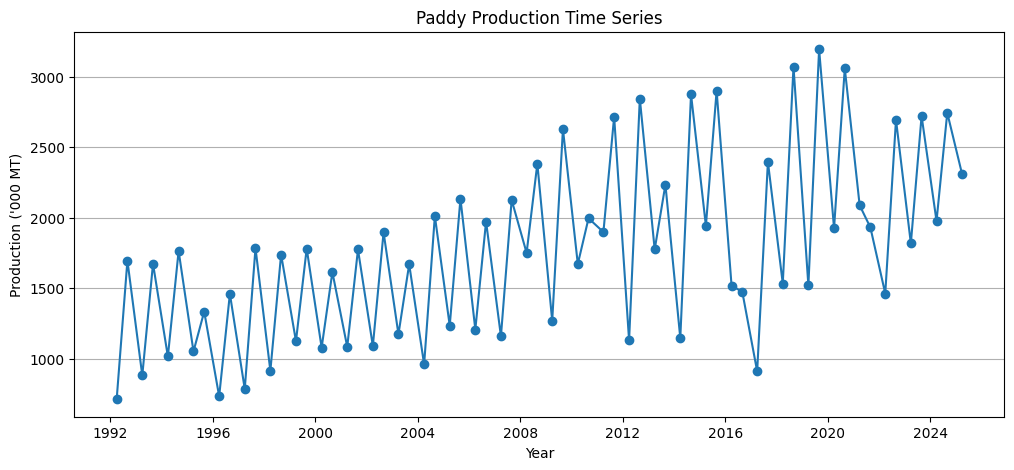

In [3]:
plt.figure(figsize=(12,5))
plt.plot(ts,marker="o")

plt.title("Paddy Production Time Series")
plt.xlabel("Year")
plt.ylabel("Production ('000 MT)")
plt.grid(axis='y')
plt.show()

In [4]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [14]:
from statsmodels.tsa.stattools import adfuller, kpss
def adf_test(series, label="Series"):
    result = adfuller(series, autolag="AIC")
    p = result[1]
    print(f"\n  ADF Test [{label}]")
    print(f"    Statistic : {result[0]:.4f}")
    print(f"    p-value   : {p:.4f}")
    print(f"    Critical 5%: {result[4]['5%']:.4f}")
    print(f"    → {'✅ STATIONARY' if p < 0.05 else '❌ NON-STATIONARY — differencing needed'}")
    return p

adf_test(ts, "Original")


  ADF Test [Original]
    Statistic : -0.4794
    p-value   : 0.8960
    Critical 5%: -2.9138
    → ❌ NON-STATIONARY — differencing needed


np.float64(0.8959678536519408)

In [5]:
# Automatically Find Best SARIMA Model
auto_model = auto_arima(train, 
                   seasonal=True,
                   test='adf', 
                   m=2, 
                   stepwise=True, 
                   suppress_warnings=True,
                   trace=True)



Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[2] intercept   : AIC=736.255, Time=0.33 sec
 ARIMA(0,0,0)(0,1,0)[2] intercept   : AIC=767.312, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[2] intercept   : AIC=750.926, Time=0.07 sec
 ARIMA(0,0,1)(0,1,1)[2] intercept   : AIC=733.322, Time=0.12 sec
 ARIMA(0,0,0)(0,1,0)[2]             : AIC=765.557, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[2] intercept   : AIC=751.915, Time=0.06 sec
 ARIMA(0,0,1)(1,1,1)[2] intercept   : AIC=734.581, Time=0.25 sec
 ARIMA(0,0,1)(0,1,2)[2] intercept   : AIC=734.320, Time=0.38 sec
 ARIMA(0,0,1)(1,1,0)[2] intercept   : AIC=744.920, Time=0.15 sec
 ARIMA(0,0,1)(1,1,2)[2] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(0,0,0)(0,1,1)[2] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,0,1)(0,1,1)[2] intercept   : AIC=734.581, Time=0.57 sec
 ARIMA(1,0,0)(0,1,1)[2] intercept   : AIC=735.088, Time=0.14 sec
 ARIMA(0,0,1)(0,1,1)[2]             : AIC=735.175, Time=0.09 sec

Best model:  ARIMA(0,0,1)(0,1,1)[2] intercept
Total fi

In [6]:

# Generate a summary of the best model found
print(auto_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   53
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 2)   Log Likelihood                -362.661
Date:                           Sat, 23 May 2026   AIC                            733.322
Time:                                   13:48:25   BIC                            741.049
Sample:                                        0   HQIC                           736.275
                                            - 53                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     35.2591     15.025      2.347      0.019       5.811      64.708
ma.L1          0.4345      0.184      2.367

In [7]:
print(auto_model.fit(train))

 ARIMA(0,0,1)(0,1,1)[2] intercept


In [8]:
forecast = auto_model.predict(n_periods=len(test))
forecast

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    2495.565291
54    1631.225599
55    2561.673592
56    1666.484654
57    2596.932647
58    1701.743709
59    2632.191702
60    1737.002765
61    2667.450757
62    1772.261820
63    2702.709813
64    1807.520875
65    2737.968868
66    1842.779930
dtype: float64

In [9]:
forecast_df = pd.DataFrame(forecast.values.round(2), index= test.index, columns=['Prediction'])
forecast_df

,Prediction
Date,
2018-09-01,2495.57
2019-04-01,1631.23
2019-09-01,2561.67
2020-04-01,1666.48
2020-09-01,2596.93
2021-04-01,1701.74
2021-09-01,2632.19
2022-04-01,1737.00
2022-09-01,2667.45


In [10]:

# pd.concat([ts, forecast_df], axis=1).plot(figsize=(12,6))

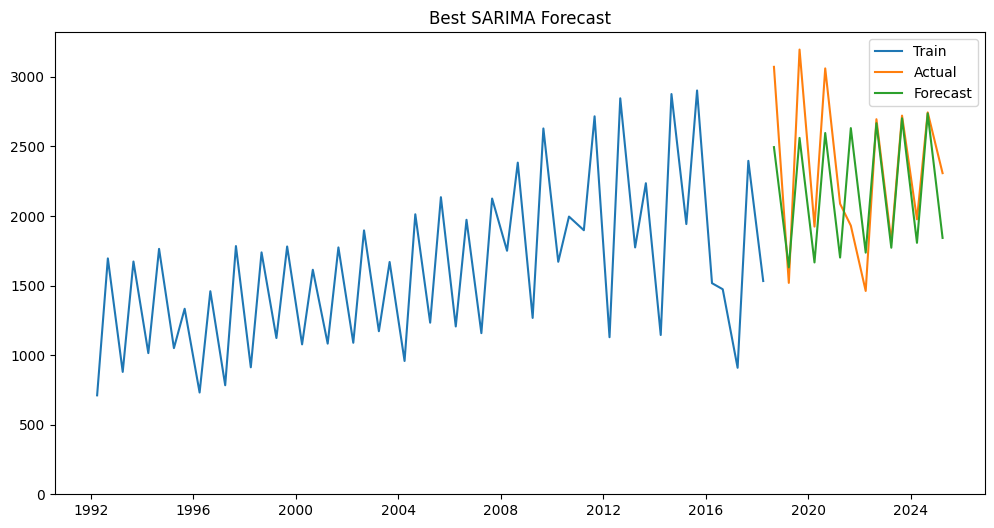

In [11]:
#Plot Forecast
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, forecast, label='Forecast')

plt.legend()

plt.title("Best SARIMA Forecast")

plt.ylim(0,)

plt.show()

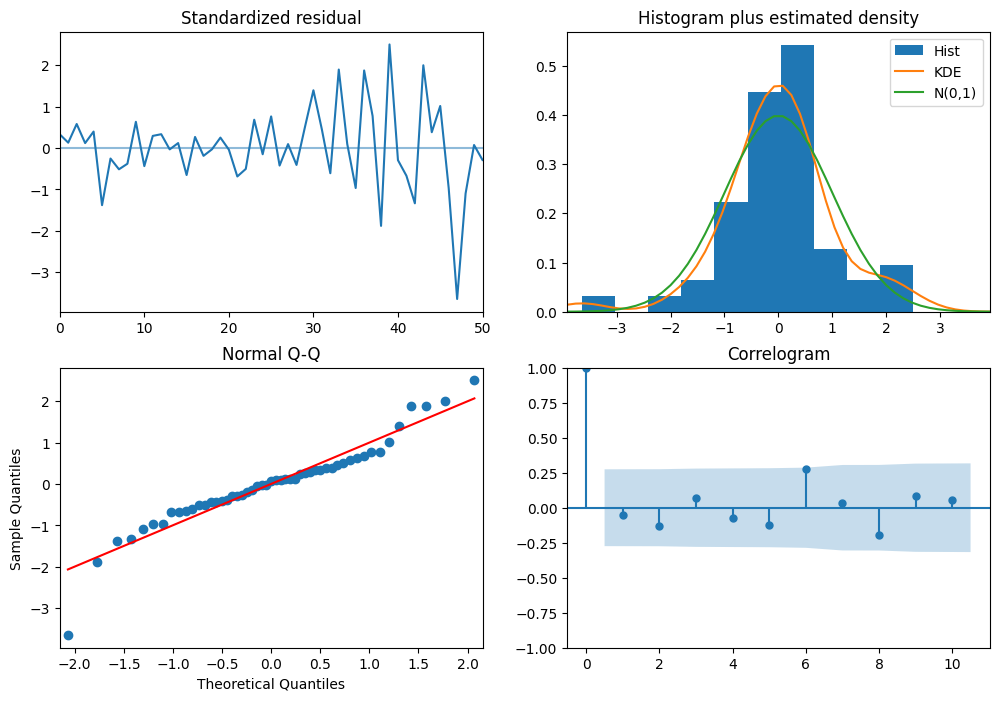

In [12]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [13]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print("RMSE :", rmse)
print("MAPE :", mape)

RMSE : 377.5872719539332
MAPE : 12.9600164456974
